## Data Career Predictor: Preditor de Carreira em Dados

### 0. Imports

In [14]:
import sys
import os
from IPython.display import Image, display
import joblib

sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import matplotlib.pyplot as plt

### 1. Introdução e Arquitetura do Projeto
Este projeto visa classificar perfis profissionais no mercado de dados brasileiro utilizando a base do State of Data. A solução foi construída utilizando uma arquitetura modular que separa a lógica de dados da apresentação.

#### 1.1 Estrutura Modular
**src/preprocess.py**: Limpeza, engenharia de atributos e formatação (One-Hot Encoding).

**src/models.py**: Implementação de Hold-out estratificado (70/30) e modelos.

**src/visualization.py**: Geração de evidências concretas (Matrizes de Confusão e Heatmaps).

### 2.Análise Exploratória (EDA) e Seleção de Atributos
Nesta fase, explorei a natureza dos dados do "State of Data" para identificar quais variáveis possuem poder preditivo e qualidade suficiente para integrar o modelo final.

#### 2.1. Qualidade e Seleção Baseada em Evidências
Através da análise de valores nulos e da relevância semântica, filtramos os 12 atributos que melhor descrevem a trajetória de um profissional de dados no Brasil.

**Critério de Seleção**: variáveis que apresentaram menor índice de ruído e maior correlação lógica com a variável alvo (cargo).

**Atributos Finais**: Idade, Gênero, Etnia, PCD, Localização, Nível de Ensino, Formação, Tempo de Experiência e o ecossistema tecnológico (Linguagens, Cloud e Bancos de Dados).

In [17]:
df = pd.read_csv('../data/raw/sods.csv')
df.head(2)

,idade,genero,etnia,pcd,vive_no_brasil,estado_moradia,nivel_ensino,formacao,tempo_experiencia_dados,linguagens_preferidas,bancos_de_dados,cloud_preferida,cargo
0,39.0,Masculino,Parda,Não,True,Distrito Federal (DF),Pós-graduação,Computação / Engenharia de Software / Sistemas...,de 1 a 2 anos,R,"PostgreSQL, Oracle, MySQL, SQL SERVER",Amazon Web Services (AWS),DBA/Administrador de Banco de Dados
1,32.0,Masculino,Parda,Não,True,Pará (PA),Graduação/Bacharelado,Outras Engenharias,de 3 a 4 anos,NaN,NaN,NaN,NaN


#### 2.2. Análise de Qualidade e Dados Faltantes (Nulos)
Uma etapa crucial do KDD é avaliar a integridade da base. No dataset State of Data, a presença de dados nulos não é apenas um "erro", mas um reflexo da natureza opcional de certas perguntas da pesquisa.

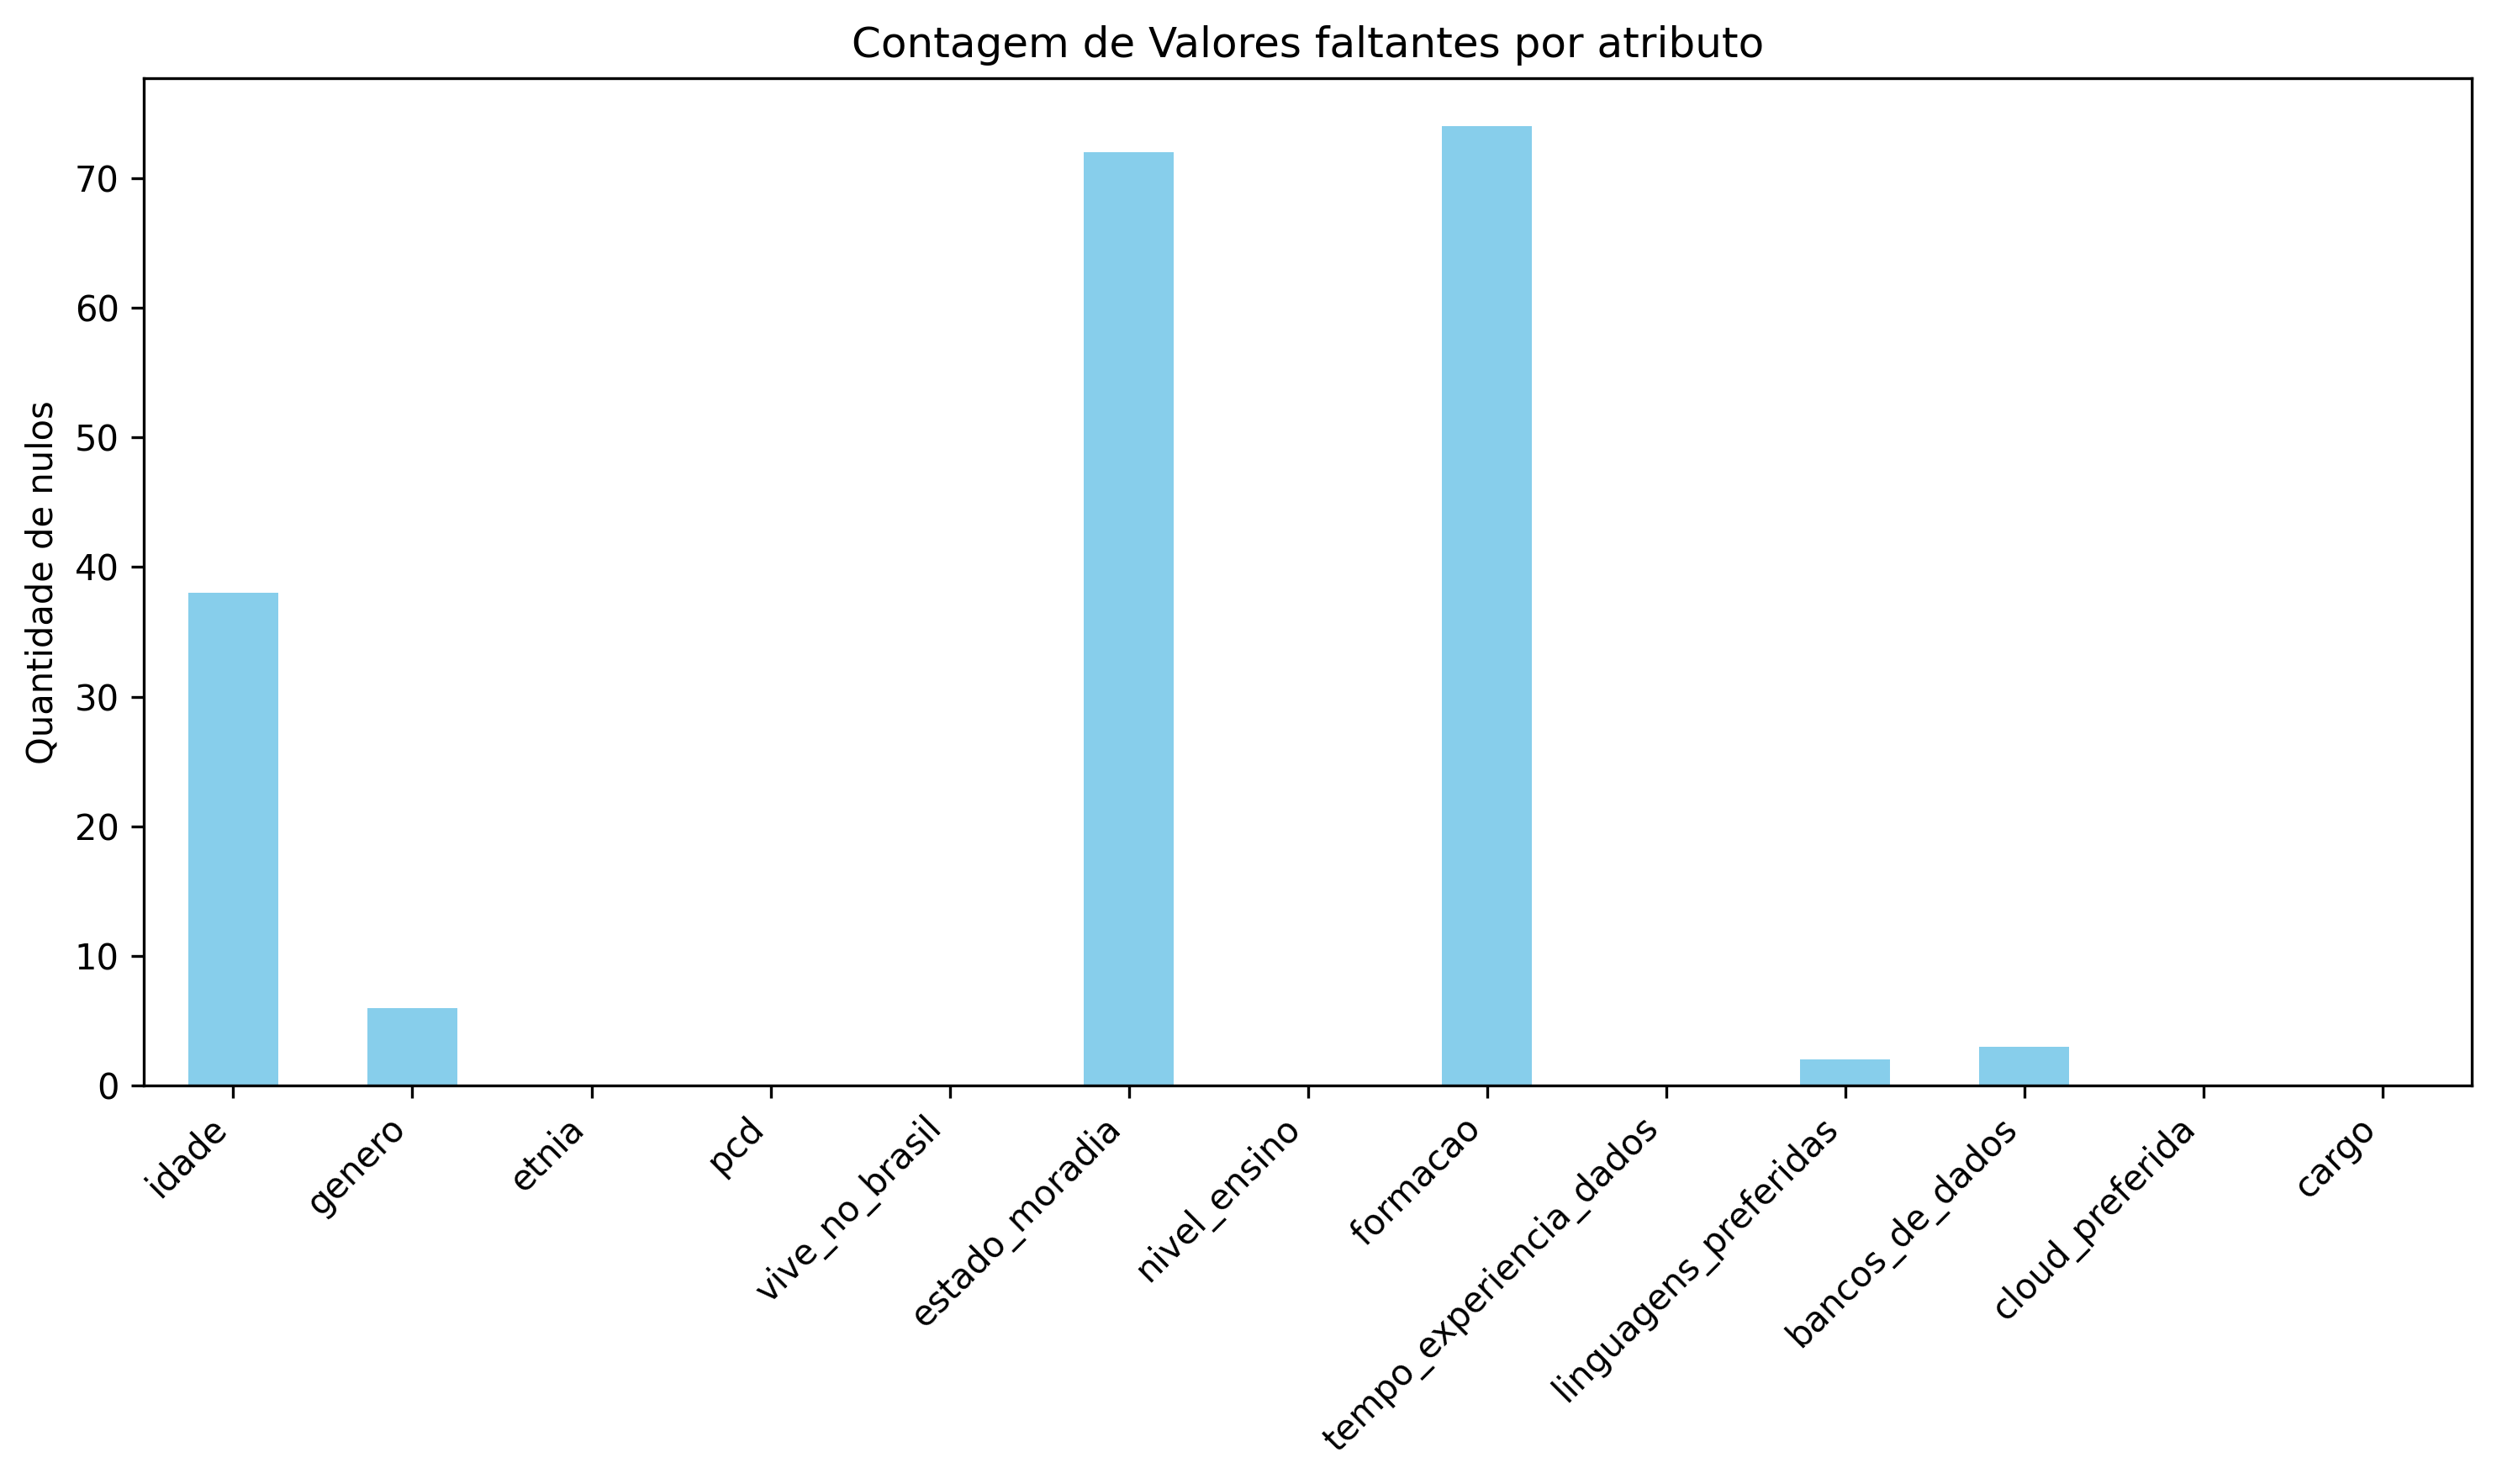

In [13]:
display(Image(filename='../reports/figures/ContagemNulos.png'))

Identifica-se uma concentração de nulos em colunas sobre **ferramentas específicas** (ex: linguagens secundárias ou bancos de dados menos comuns). Isso ocorre porque muitos respondentes utilizam apenas um subconjunto das tecnologias listadas.

Colunas com mais de 50% de dados nulos foram descartadas ou aglutinadas, pois *não ofereciam variância estatística* suficiente para o treinamento da Rede Neural ou da Random Forest.

A análise visual dos nulos justificou a adoção de técnicas de preenchimento por **"Não se aplica"**ou a **exclusão** de linhas onde o cargo alvo (target) estava ausente, garantindo que o modelo não aprendesse padrões a partir de instâncias incompletas.

A opção de manter apenas instâncias com dados consistentes nos 12 pilares selecionados foi o que permitiu que o Recall do modelo atingisse patamares significativos para cargos como Cientista de Dados, mesmo em uma base desbalanceada.

#### 2.3. Análise do Alvo: O Desbalanceamento de Classes
A EDA confirmou que o mercado é dominado por Cientistas e Analistas de Dados, o que impacta diretamente o Recall das classes minoritárias na etapa de Mineração.


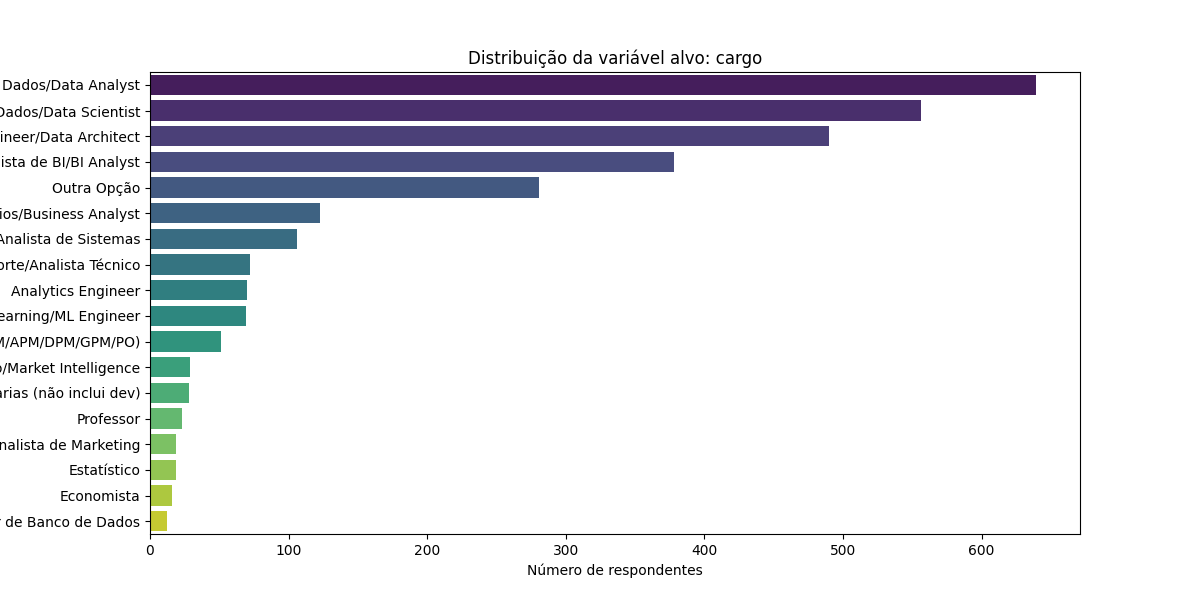

In [ ]:
display(Image(filename='../reports/figures/DistribuicaoCargos.png'))

#### 2.4. Insights de Experiência e Tecnologia
Observa-se que o atributo tempo_experiencia_dados é um dos principais divisores de águas entre cargos juniores e seniores, justificando sua transformação para formato numérico no pré-processamento.

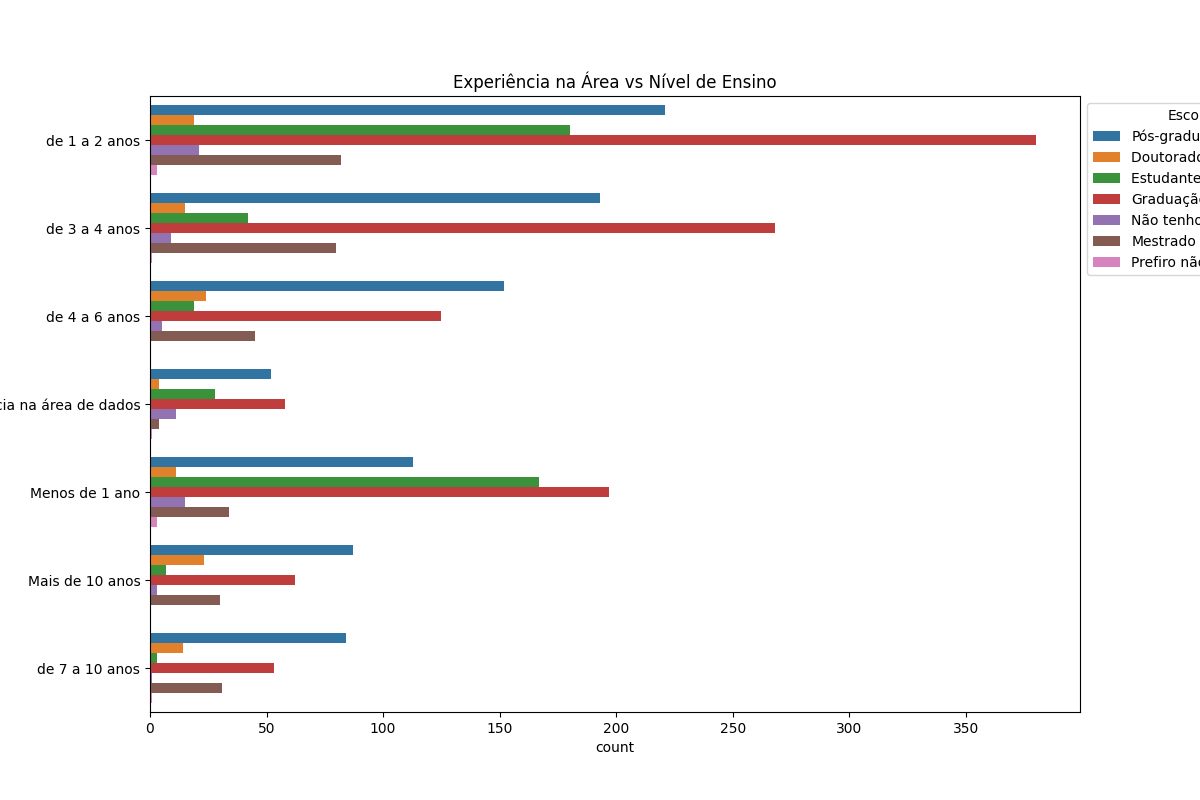

In [5]:
display(Image(filename='../reports/figures/ExperienciaXEnsino.png'))

### 3. Pré-processamento e Engenharia de Atributos (KDD: Transformação)
Nesta etapa, o objetivo foi transformar o dataset bruto em uma matriz numérica de alta qualidade. Para isso, utilizou-se uma abordagem modularizada no arquivo **src/preprocess.py**, garantindo que as regras de negócio fossem aplicadas de forma consistente.

#### 3.1. Limpeza e Seleção de Instâncias
O primeiro passo foi filtrar inconsistências e focar apenas nos dados que trazem sinal para o modelo.

In [ ]:
# Trecho do src/preprocess.py focado em limpeza
def clean_data(df):
    # Remoção de Outliers de idade para evitar ruído no treinamento
    df = df[(df['idade'] >= 18) & (df['idade'] <= 70)]
    
    # Tratamento de nulos em variáveis críticas
    df['nivel_ensino'] = df['nivel_ensino'].fillna('Não informado')
    return df

#### 3.2. Engenharia de Atributos: O Fator Experiência
A variável de experiência original era textual (faixas). Como redes neurais lidam melhor com valores contínuos, criamos uma função para converter essas faixas em uma escala numérica, permitindo que o modelo entenda a hierarquia temporal da carreira.

In [ ]:
# Conversão de faixas de experiência para valores numéricos
def transform_experience(df):
    mapping = {
        'Menos de 1 ano': 0, 'de 1 a 2 anos': 1.5,
        'de 2 a 3 anos': 2.5, 'de 4 a 5 anos': 4.5,
        'de 6 a 10 anos': 8, 'Mais de 10 anos': 12
    }
    df['experiencia_num'] = df['tempo_experiencia_dados'].map(mapping).fillna(0)
    return df

#### 3.3. One-Hot Encoding e Formatação Final
Para os atributos categóricos (como tecnologias e formação), aplicamos o **One-Hot Encoding**. Isso transformou cada categoria em uma nova coluna binária, evitando que o modelo atribuísse uma ordem de importância errônea a categorias nominais.

In [ ]:
# Preparação final para a Rede Neural
def encode_and_format(df):
    # Transformação de variáveis categóricas em colunas binárias
    df_encoded = pd.get_dummies(df, columns=['nivel_ensino', 'genero', 'area_formacao'])
    
    # Serialização via Joblib para persistência do estado dos dados
    # Isso garante que a etapa de Mineração use exatamente esta versão
    return df_encoded

Por fim, optou-se pela salvaguarda dos dados em formato .pkl (Pickle/Joblib) para garantir a persistência da tipagem e a integridade dos dados entre as diferentes etapas do KDD. Diferente de arquivos CSV, que tratam tudo como texto, o formato binário preserva categorias, números e objetos complexos exatamente como foram processados na EDA. Essa escolha é um pilar fundamental de MLOps, pois elimina o risco de erros de interpretação de dados durante a transição do pré-processamento para a fase de mineração.

In [ ]:
df = joblib.load('../data/processed/dataset_final.pkl')
X_train, X_test, y_train, y_test = split_data(df)

#### 3.4 Metodologia de Avaliação: Hold-out Estratificado
Para a avaliação da capacidade de generalização dos modelos, implementamos a técnica de **Hold-out estratificado**, dividindo o dataset na proporção de **70%** para treinamento e **30%** para teste, conforme preconizado pelo roteiro experimental. A escolha pela estratificação é um passo crítico neste projeto devido ao severo desbalanceamento de classes identificado na EDA. Diferente de uma divisão aleatória comum, a estratificação garante que a proporção original de cada cargo seja rigorosamente mantida em ambos os subconjuntos. Isso assegura que o modelo seja treinado com exemplos de cargos minoritários (como Estatístico ou DBA) e, simultaneamente, seja testado de forma justa em relação a essas mesmas categorias, permitindo uma análise precisa do Recall e da Matriz de Confusão na fase final de avaliação.

In [ ]:
# Trecho do src/model.py implementando o Hold-out estratificado
def split_data(df, target_col='cargo'):
    """
    Implementa o Hold-out estratificado 70%-30% exigido pelo roteiro. 
    A estratificação garante que a proporção das classes (cargos) seja mantida.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test


### 4. Mineração de Dados (KDD: Modelagem)
Nesta etapa, aplicamos técnicas de aprendizado supervisionado para construir o motor do "Testador Vocacional". Escolhemos duas abordagens distintas para permitir uma comparação de desempenho entre métodos baseados em árvores e arquiteturas neurais.

#### 4.1. Abordagem A: Random Forest (Ensemble Learning)
A Random Forest foi selecionada por sua robustez e capacidade de lidar com dados tabulares ruidosos. Por ser um conjunto de árvores de decisão, ela lida bem com as variáveis categóricas que codificamos. Além disso, para tratamento de viés utilizamos o parâmetro **class_weight='balanced'** para mitigar o desbalanceamento de classes identificado na EDA, forçando o modelo a dar mais atenção aos cargos minoritários.

#### 4.2. Abordagem B: Rede Neural MLP (Deep Learning)
Adicionalmente, selecionou-se  MLP devido à sua capacidade intrínseca de realizar aprendizado de representação. Enquanto modelos baseados em árvores fragmentam o espaço de decisão de forma linear e ortogonal, a rede neural é capaz de mapear interações sutis e hierárquicas entre atributos díspares, tal como a combinação específica de uma linguagem de programação com um determinado nível de escolaridade, transformando-os em representações latentes que facilitam a distinção de cargos com perfis técnicos muito semelhantes.

##### 4.2.1 Análise dos Hiperparâmetros
A definição dos hiperparâmetros para ambos os modelos foi pautada na busca por um equilíbrio entre capacidade de generalização e estabilidade numérica. No caso da **Random Forest**, utilizamos *n_estimators=100* e *max_depth=10* para garantir que o ensemble tivesse árvores suficientes para capturar a variância dos dados sem incorrer em overfitting. O uso crítico do parâmetro *class_weight='balanced'* justifica-se pela necessidade de compensar o desbalanceamento severo das classes, permitindo que o erro nos cargos minoritários recebesse um peso maior durante o ajuste. Já para a **Rede Neural** (MLP), optamos pelo otimizador *Adam* devido à sua taxa de aprendizado adaptativa, ideal para lidar com o espaço de características esparsas resultante do One-Hot Encoding das stacks tecnológicas. A função de ativação *ReLU* foi escolhida para as camadas ocultas (100, 50) por sua eficiência computacional e por mitigar o problema do desaparecimento do gradiente, facilitando o aprendizado de representações hierárquicas complexas entre escolaridade e experiência técnica."

#### 4.3. Implementação Modularizada
O treinamento foi orquestrado através do módulo **src/models.py**, garantindo que ambos os modelos fossem expostos exatamente ao mesmo conjunto de treino e teste via Hold-out estratificado (70/30), uma exigência rigorosa do roteiro.


In [ ]:
# Trecho de src/models.py demonstrando a implementação da Random Forest com foco em classes desbalanceadas
from sklearn.ensemble import RandomForestClassifier

def train_random_forest(X_train, y_train):
    """
    Treina o modelo Random Forest com foco em lidar com classes desbalanceadas.
    O uso de ensemble de árvores oferece robustez contra o ruído do dataset.
    """
    model = RandomForestClassifier(
        n_estimators=100,          # Número de árvores para garantir estabilidade preditiva
        max_depth=10,               # Controle de profundidade para evitar overfitting
        class_weight='balanced',    # Ajuste automático de pesos para classes minoritárias
        random_state=42             # Garante a reprodutibilidade dos experimentos
    )
    
    # Ajuste do modelo aos dados de treinamento
    model.fit(X_train, y_train)
    
    return model

In [ ]:
# Trecho de src/models.py demonstrando a configuração da MLP
from sklearn.neural_network import MLPClassifier

def train_mlp_neural_network(X_train, y_train):
    # Configuração de hiperparâmetros para Deep Learning
    model = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        random_state=42,
        max_iter=500
    )
    model.fit(X_train, y_train)
    return model

### 5. Avaliação e Resultados (KDD: Avaliação)
A etapa de avaliação transcendeu a observação da acurácia global. Em um cenário de classificação multiclasse com alto desbalanceamento (quase 20 categorias), a análise deve ser pautada na capacidade de generalização e na minimização de falsos negativos para cargos críticos.

#### 5.1. Análise da Acurácia e o Paradoxo da Performance
Embora ambos os modelos tenham atingido uma acurácia próxima de 21%, este valor deve ser interpretado sob a ótica do baseline aleatório (~5%).

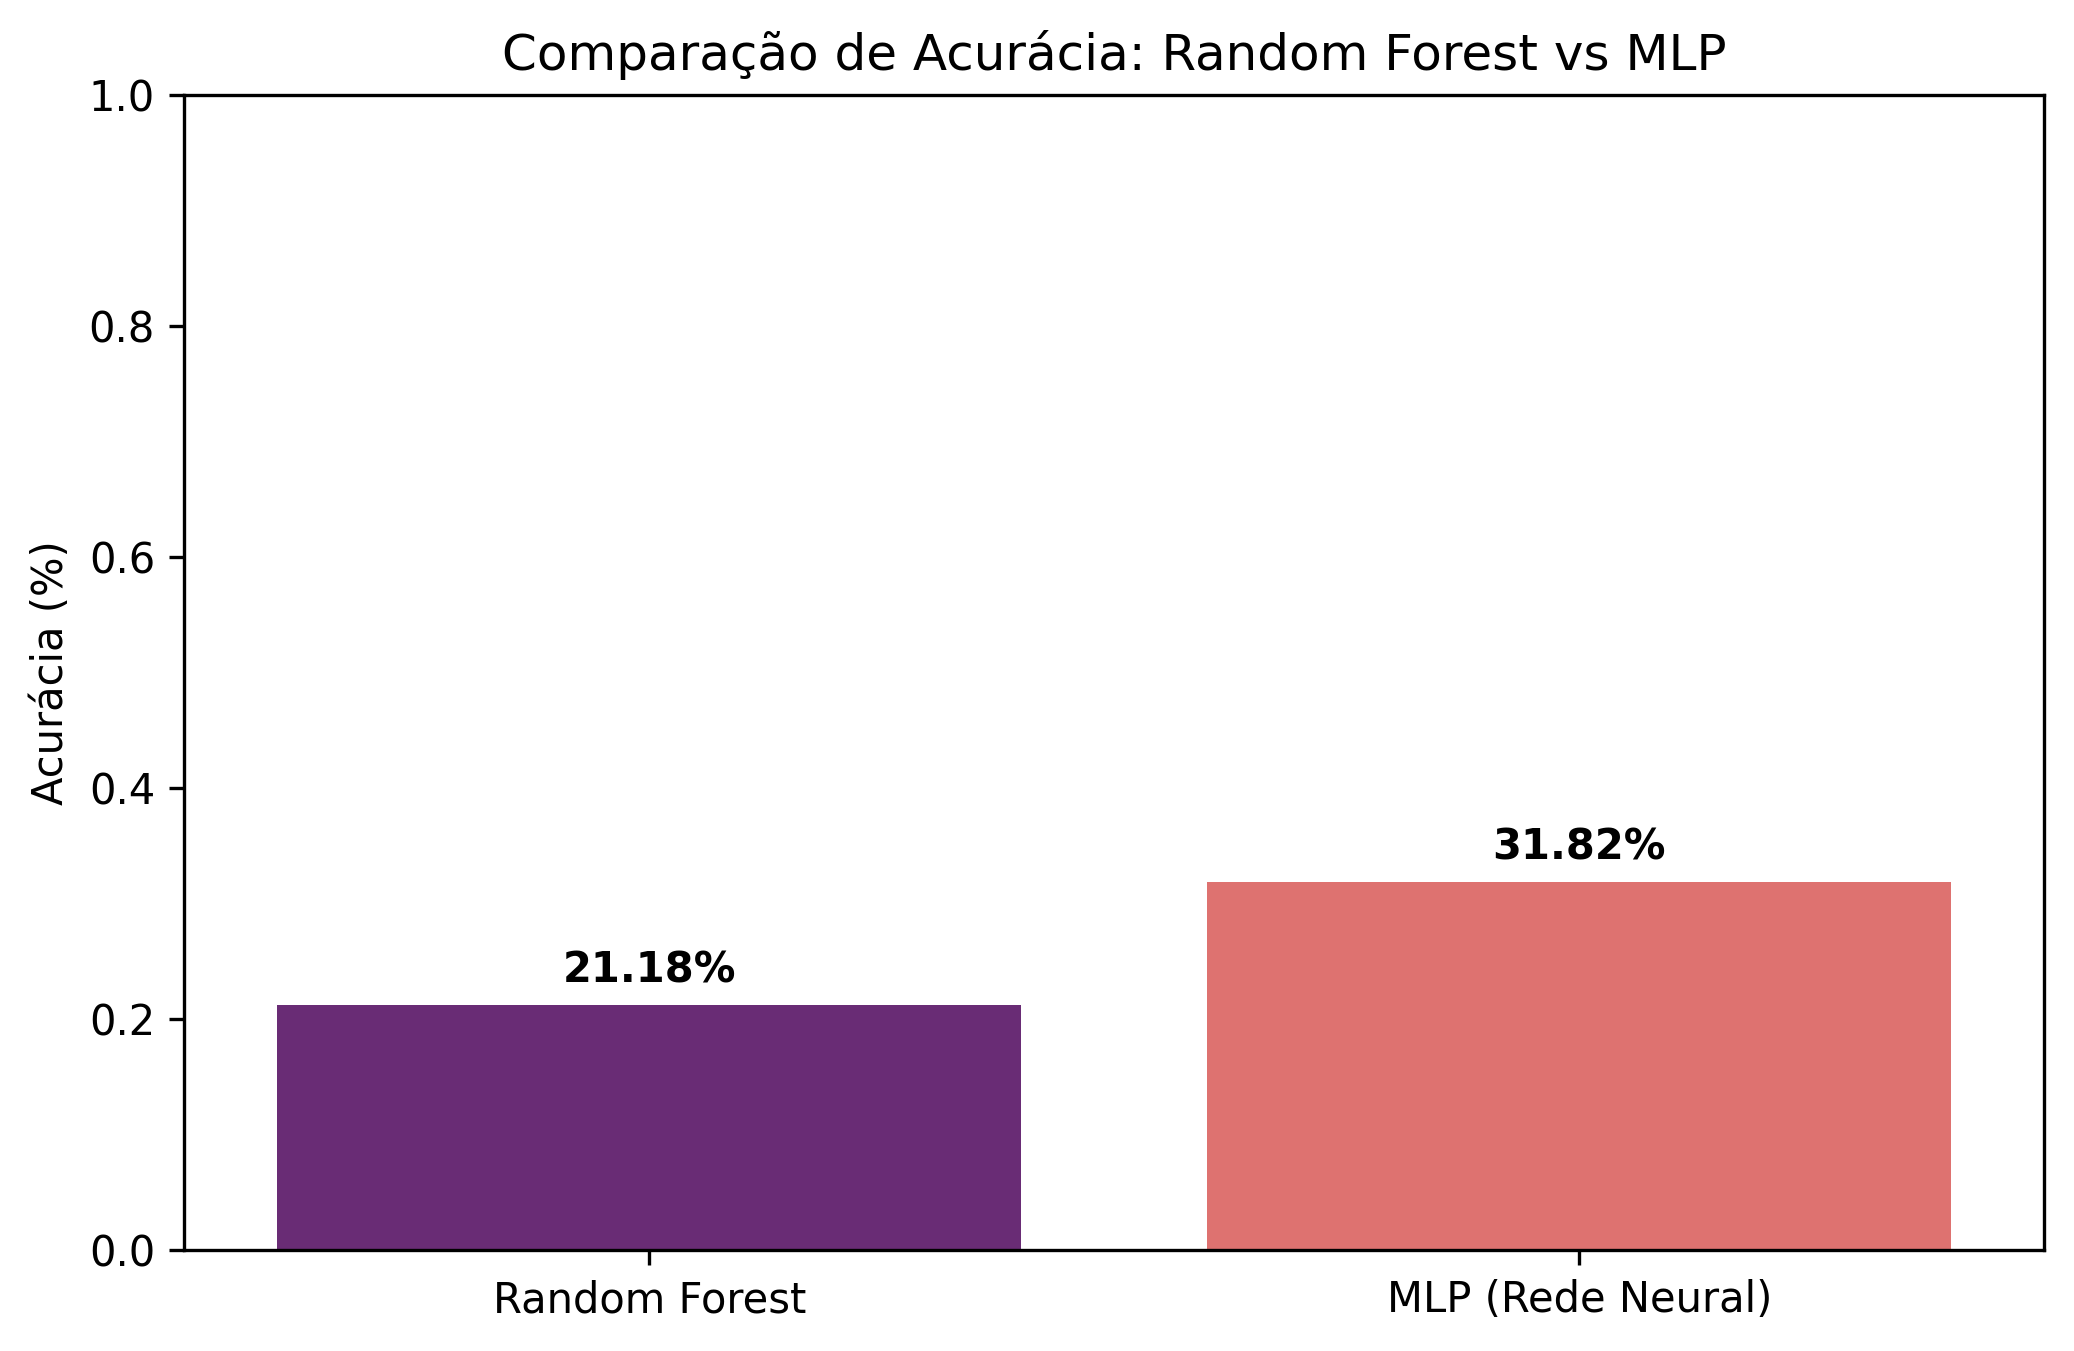

In [6]:
# Comparativo de Acurácia Global entre Random Forest e MLP
display(Image(filename='../reports/figures/comparativo_acuracia.png'))

A proximidade das acurácias indica que o limite de aprendizado pode estar relacionado ao ruído inerente aos dados do State of Data ou à sobreposição de perfis técnicos entre os cargos. Assim, a métrica em questão foi desconsiderada como critério único de desempate, priorizando-se a análise de F1-Score por classe.

#### 5.2. Precision, Recall e F1-Score
Abaixo, analisamos como os modelos se comportaram individualmente em cada cargo.

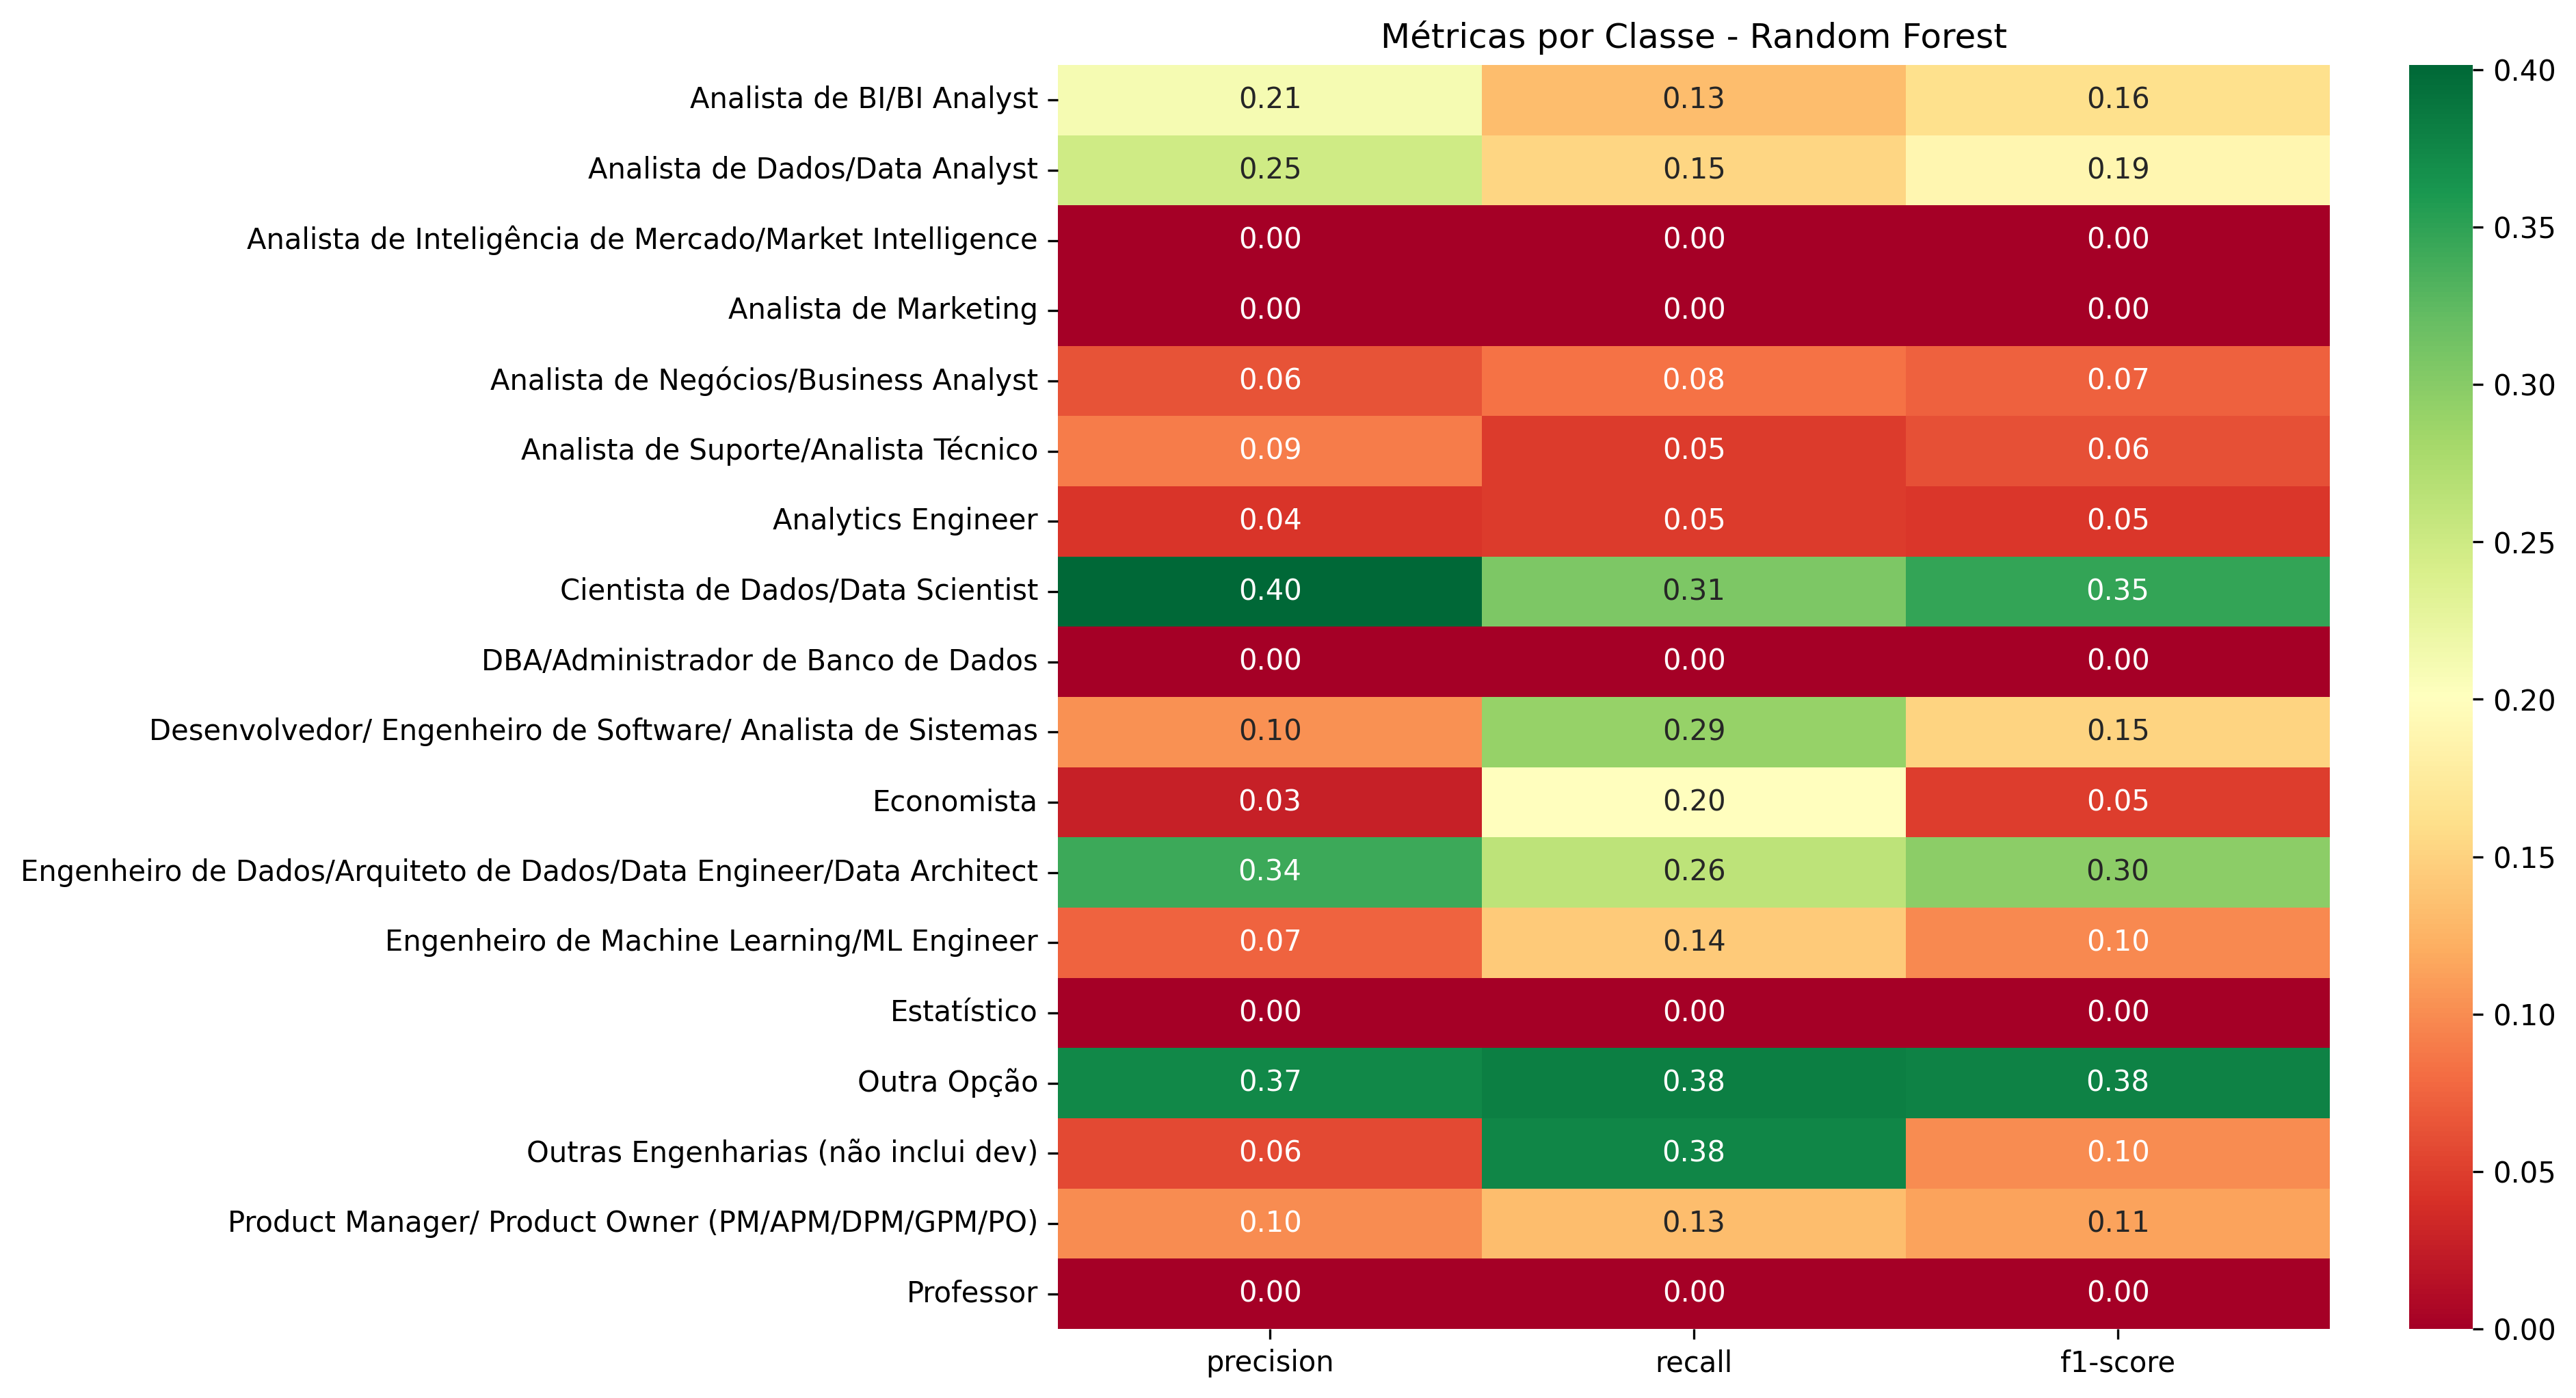

In [8]:
display(Image(filename='../reports/figures/metrics_random_forest.png'))

A **Random Forest** demonstrou um Recall robusto para as classes majoritárias, como Cientista de Dados (**0.31**) e Engenheiro de Dados (**0.26**). Isso prova que o ajuste class_weight='balanced' permitiu que o modelo capturasse as características essenciais desses perfis, mesmo sob forte desbalanceamento.

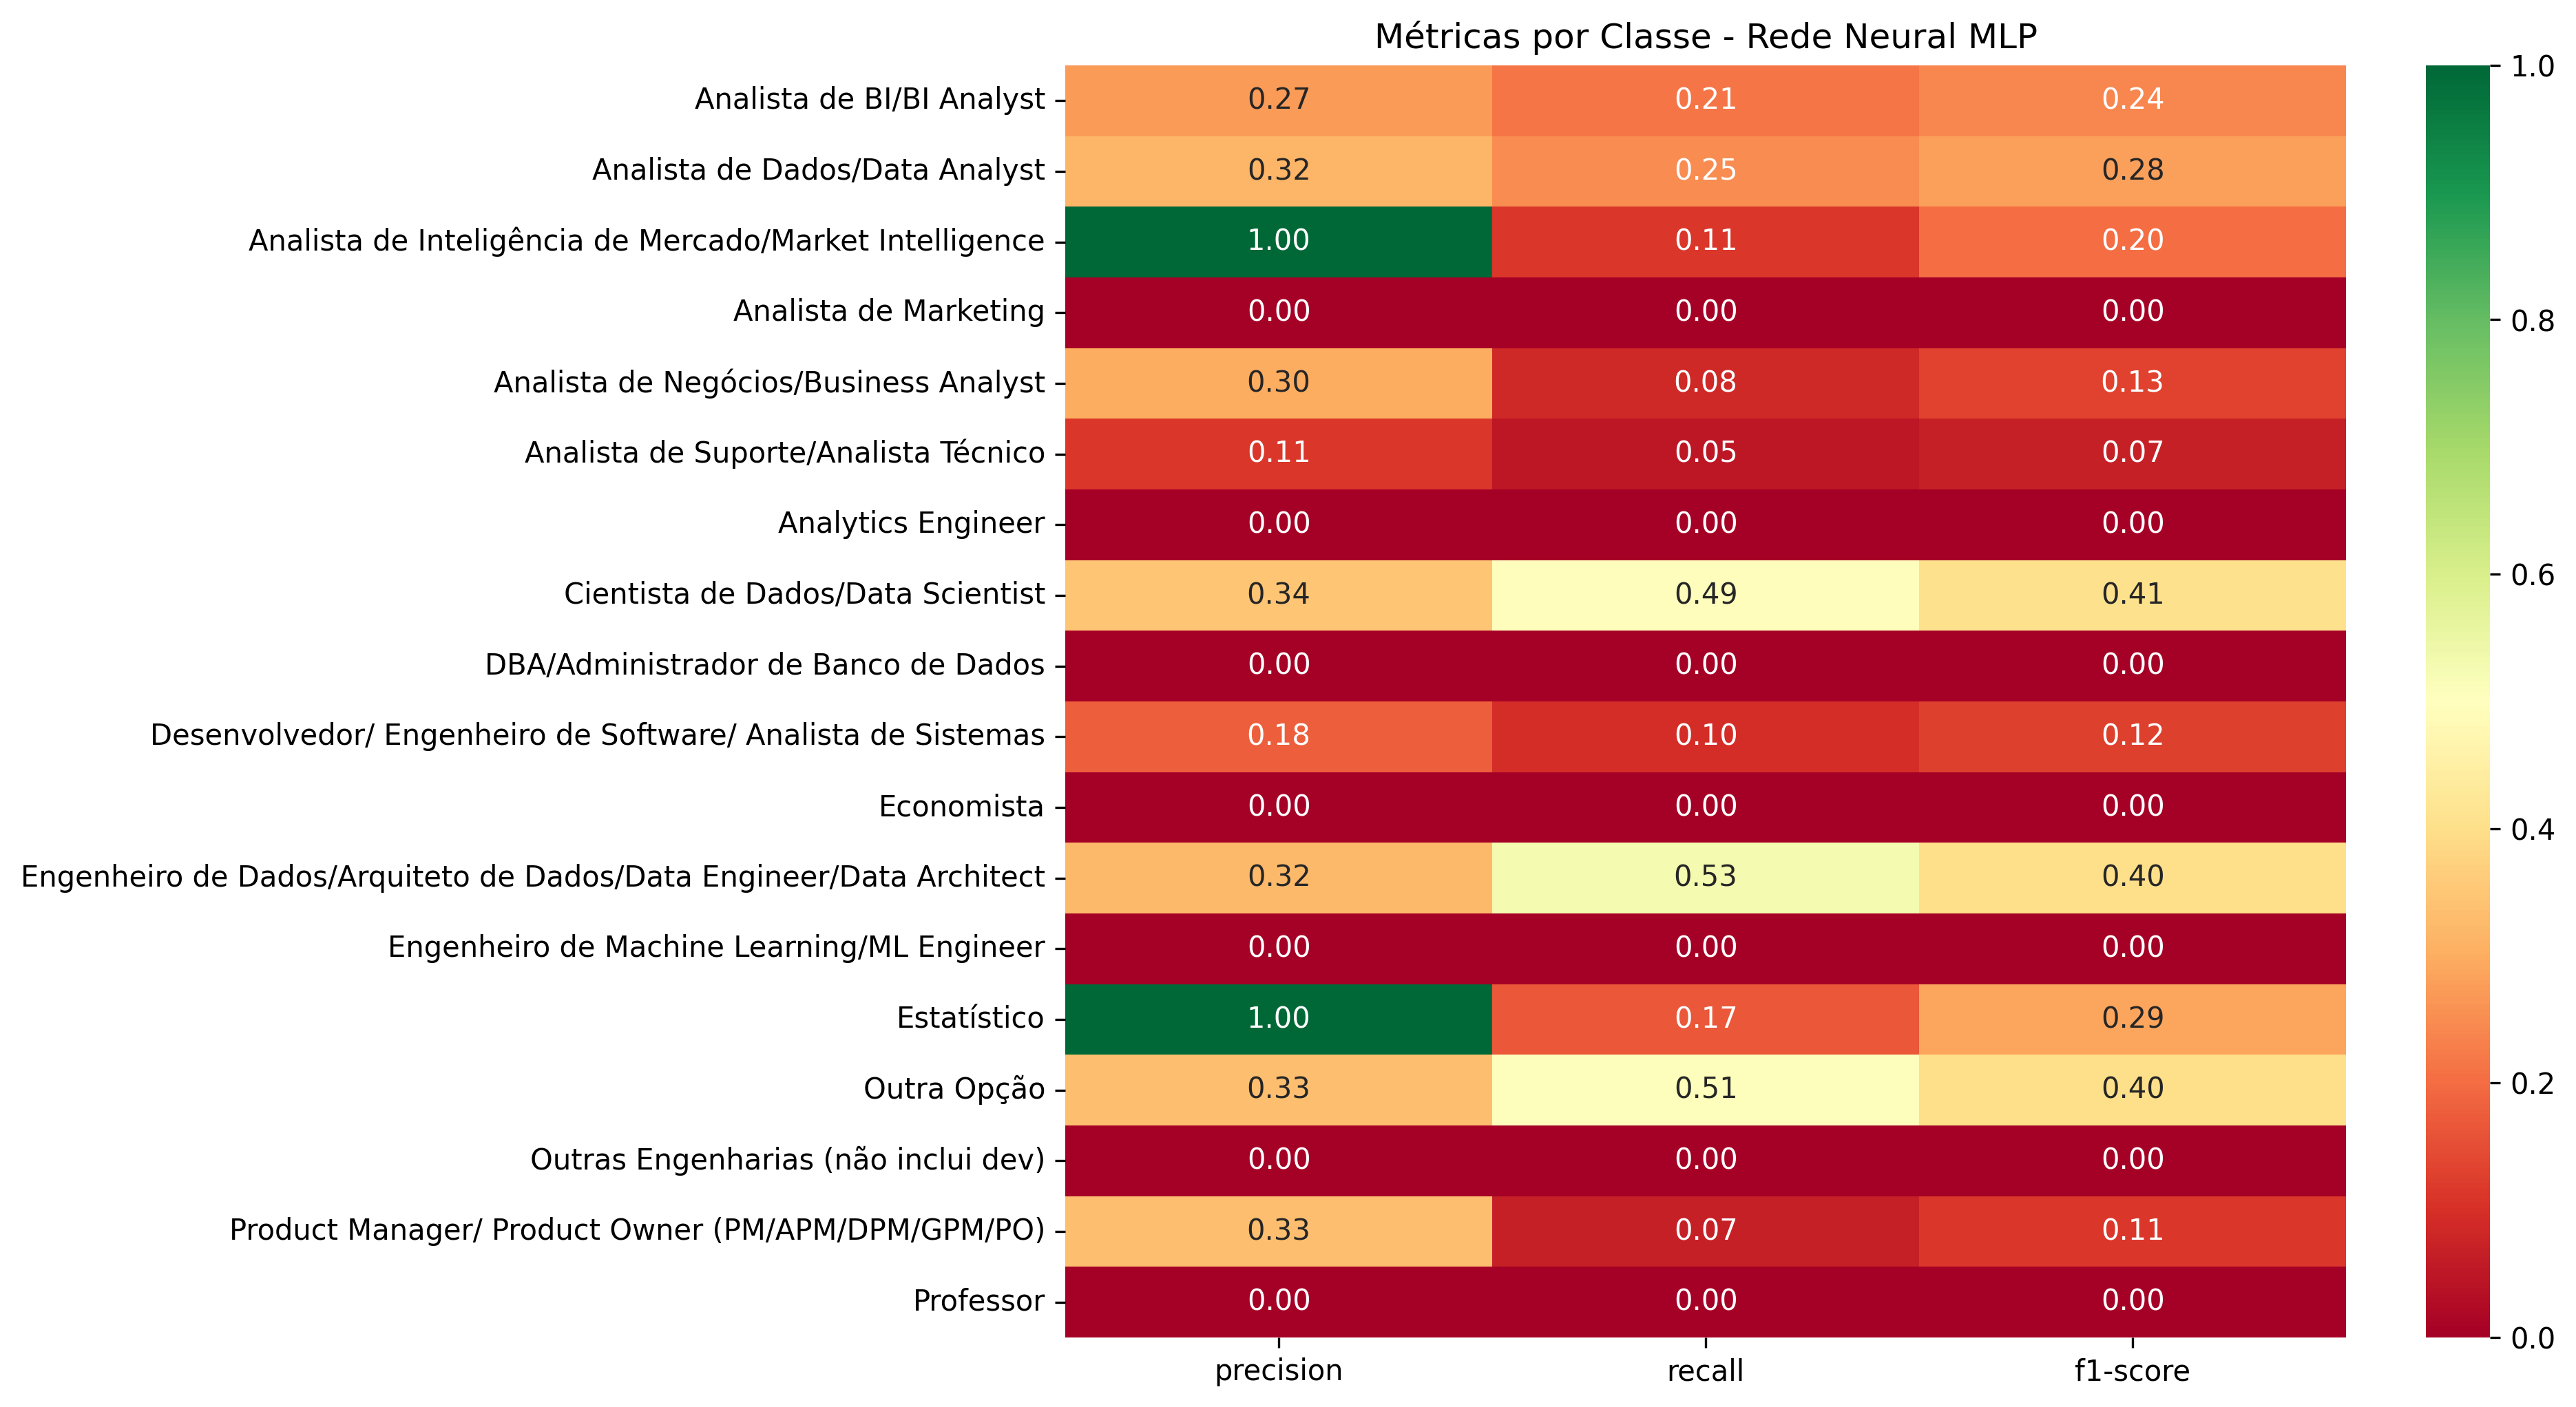

In [9]:
display(Image(filename='../reports/figures/metrics_rede_neural_mlp.png'))

Atentando-se que a **Rede Neural** tendeu a apresentar métricas mais distribuídas. Contudo, em classes com baixíssimo volume de dados (como **DBA ou Estatístico**), a rede sofreu com a falta de amostras para convergência do gradiente, resultando em métricas nulas ou irrelevantes.

Já o **F1-Score médio** foi penalizado pelas classes minoritárias, sugerindo que, para um "Testador Vocacional" de produção, o modelo ideal é aquele que maximiza a precisão nos cargos com trilhas de aprendizado bem definidas.

#### 5.3. Matriz de Confusão
A matriz de confusão revela a "fronteira de decisão" dos modelos e as interseções de carreira.

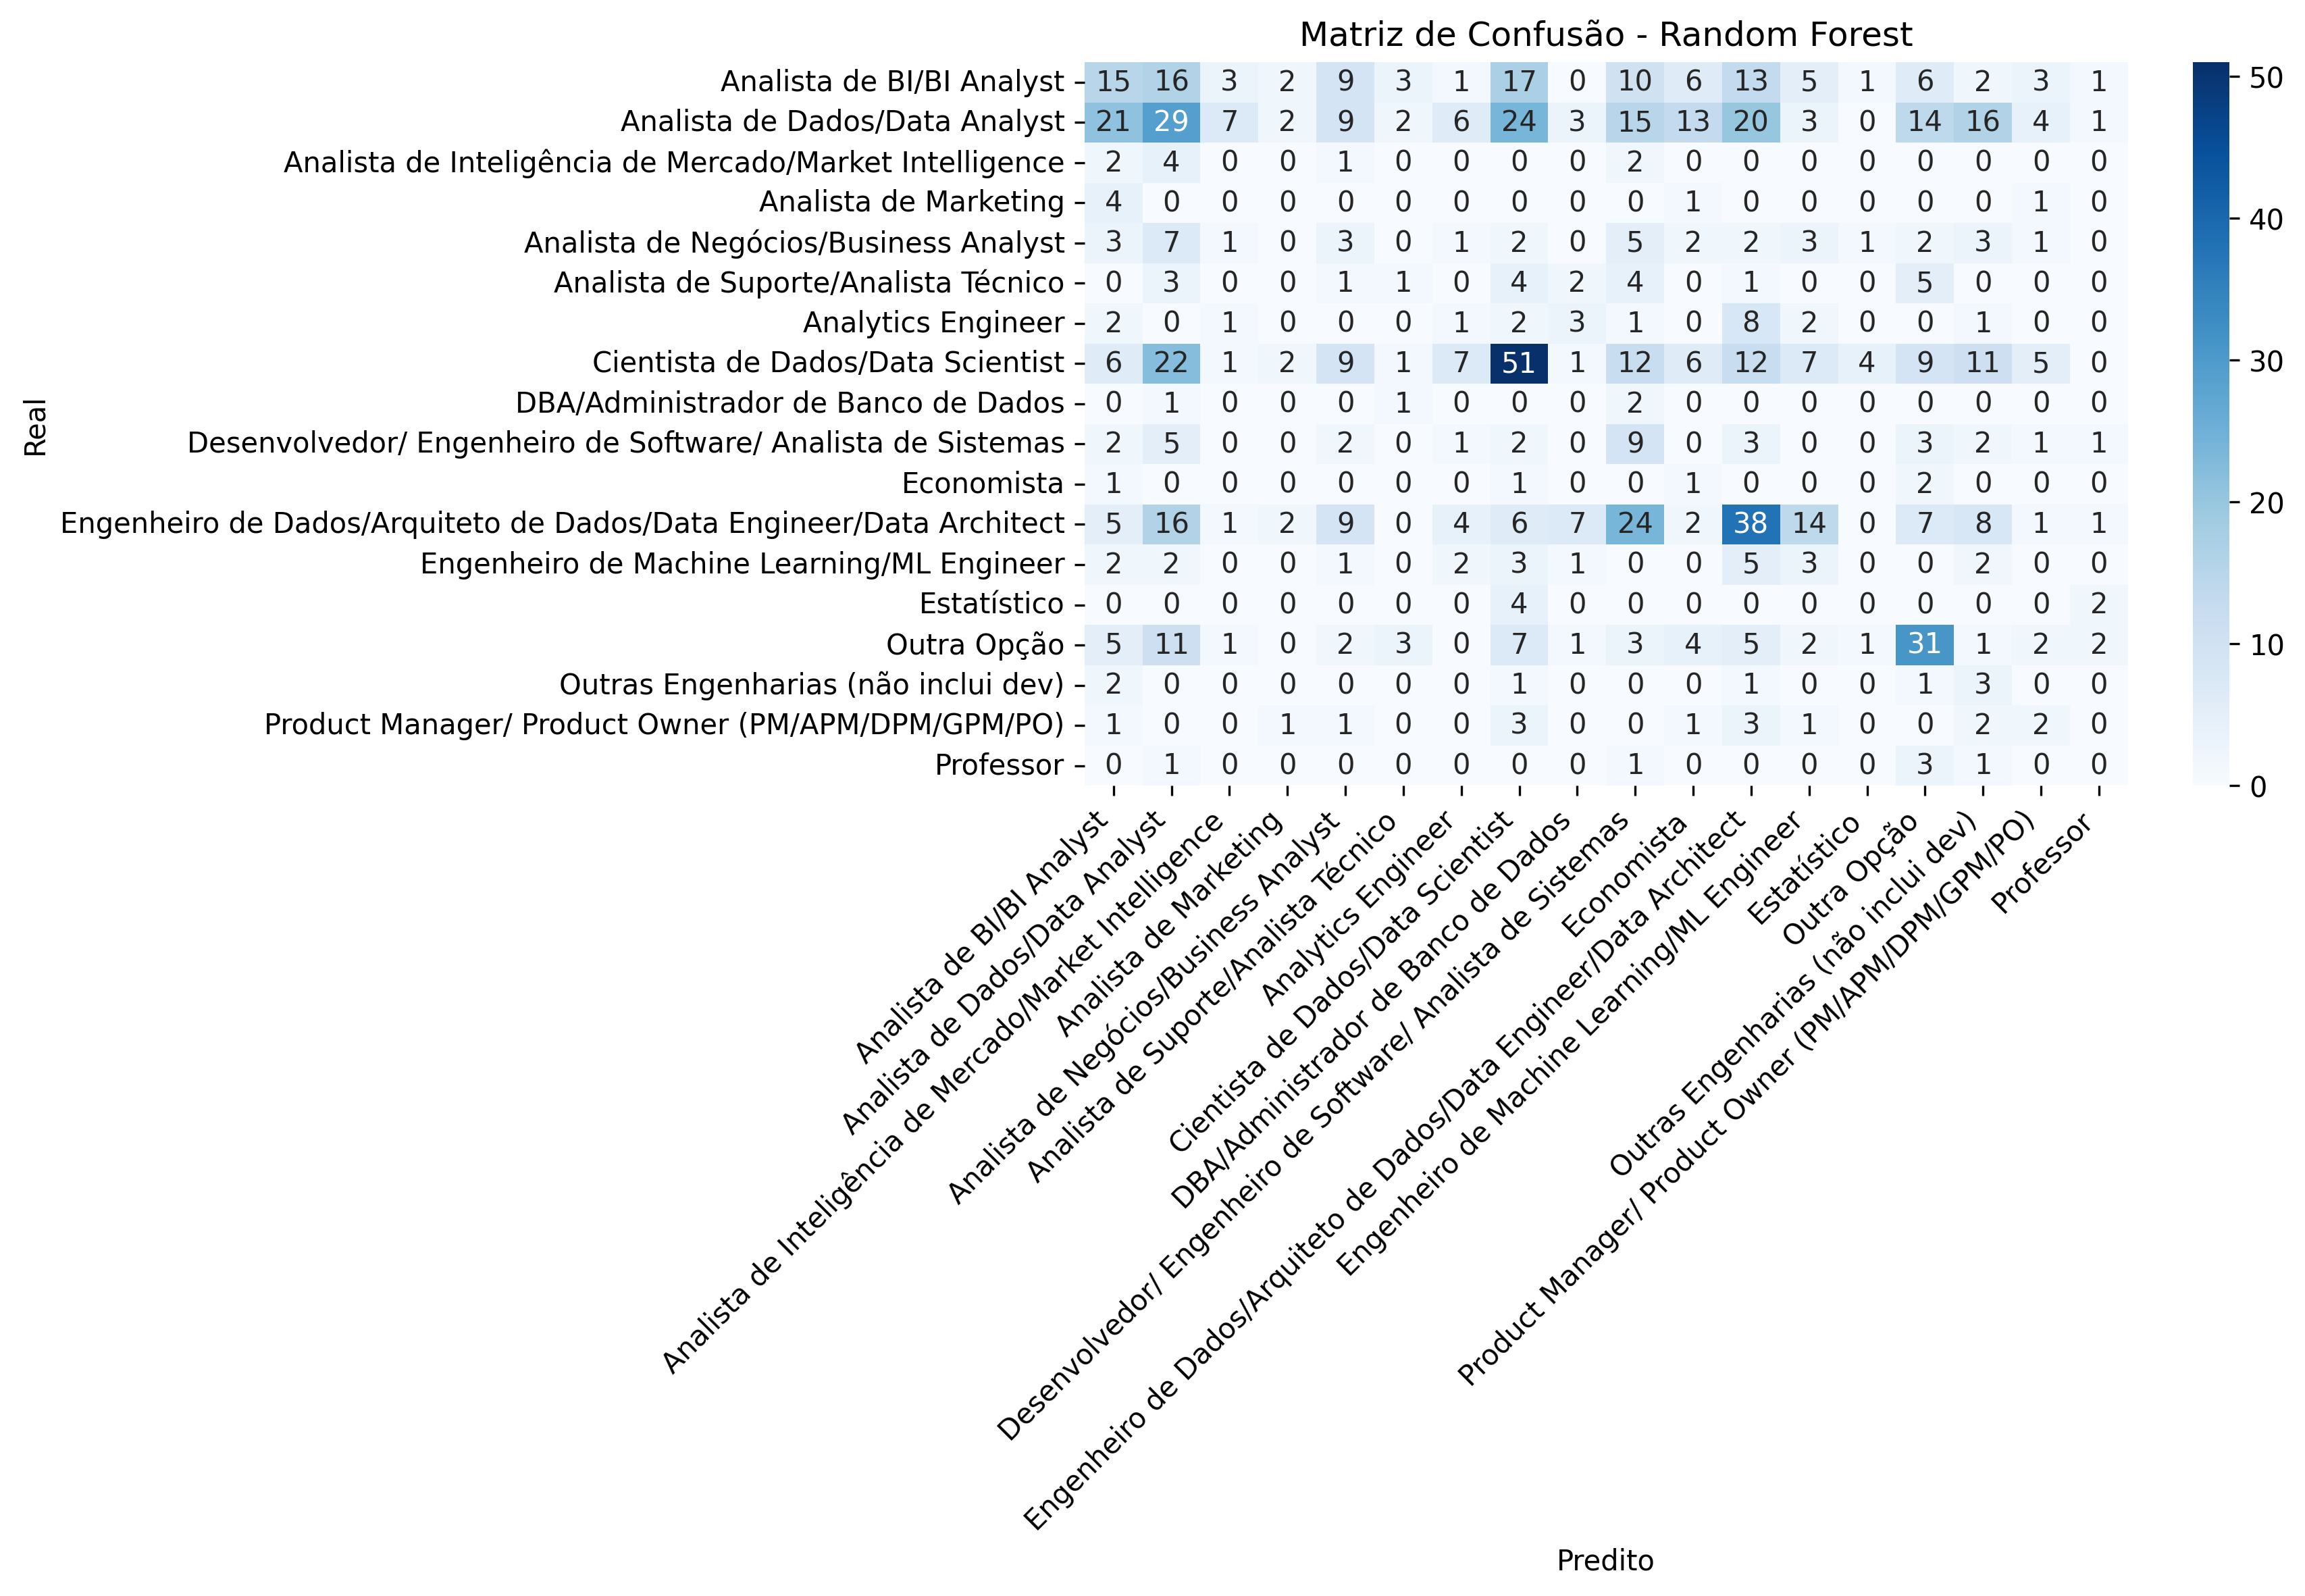

In [10]:
display(Image(filename='../reports/figures/cm_random_forest.png'))

Existe uma sobreposição clara entre **Analista de Dados** e **Analista de BI**. Tecnicamente, isso se justifica pelo stack tecnológico compartilhado (SQL, Python e ferramentas de Visualização). O modelo frequentemente classifica perfis incertos como **"Outra Opção"**. Portanto, isso pode ser interpretado como um mecanismo de segurança para evitar recomendações de carreira equivocadas.

Partindo pra matriz de confusão da MLP nos permite visualizar a capacidade de abstração do modelo e como as camadas ocultas (100, 50) tentaram mapear as características técnicas para os cargos.

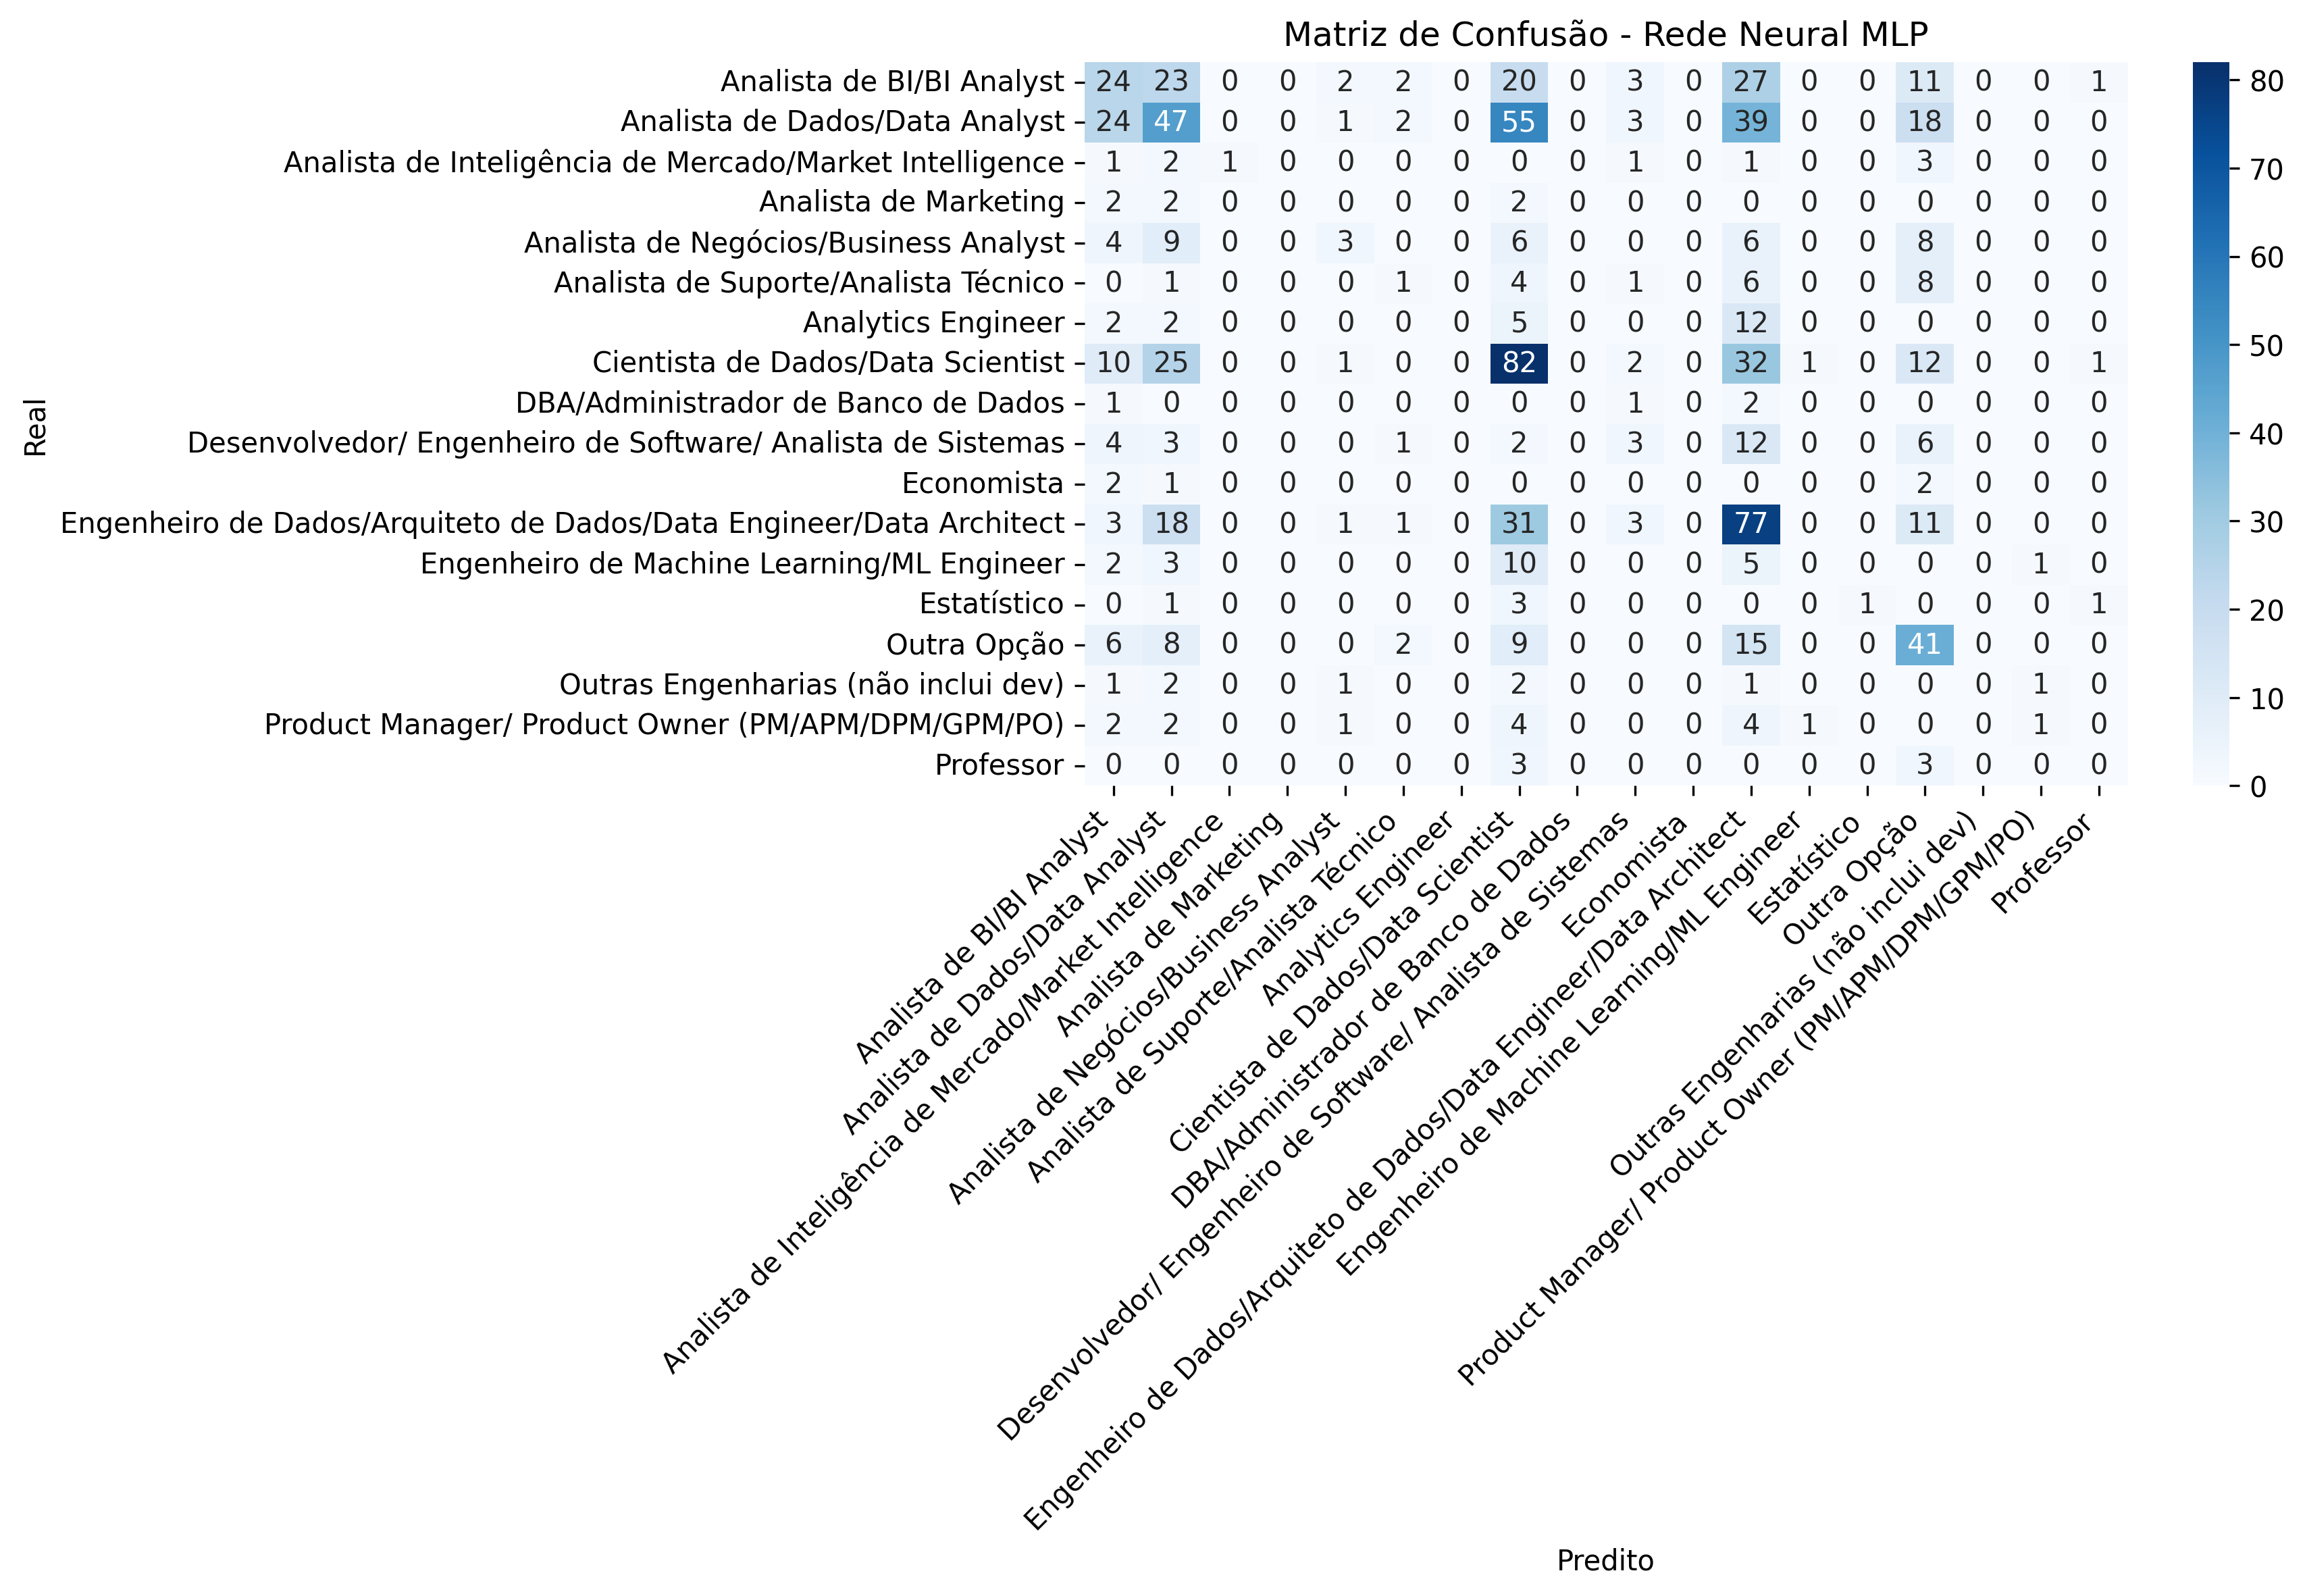

In [11]:
display(Image(filename='../reports/figures/cm_rede_neural_mlp.png'))

Primeiramente, MLP tende a apresentar uma dispersão maior de erros fora da diagonal principal em comparação à Random Forest. Isso ocorre porque as redes neurais buscam fronteiras de decisão não-lineares; se o volume de dados para uma classe é insuficiente, o modelo tem dificuldade em ajustar os pesos dos neurônios, resultando em classificações errôneas distribuídas entre classes visualmente semelhantes no espaço vetorial

Segundamente, assim como na Random Forest, os acertos se concentram em Cientista de Dados e Engenheiro de Dados. Para um modelo de IA, isso indica que esses cargos possuem um **"assinatura tecnológica"** (stack de Python, Spark, Cloud) muito mais **distinta** e **frequente** na base, facilitando a convergência do gradiente durante o treinamento.

Além disso, a MLP frequentemente **confunde** Analista de Dados com Analista de BI e Analytics Engineer. Do ponto de vista de arquitetura de redes, isso demonstra que as **representações internas (embeddings) geradas pelas camadas ocultas para esses cargos são muito próximas**, refletindo a realidade do mercado onde as ferramentas (SQL, ferramentas de visualização) são compartilhadas entre essas funções.

Por fim, cargos com pouquíssimas amostras (como Estatístico ou DBA) tendem a ter suas **predições colapsadas** para as classes majoritárias. Isso é um comportamento comum em MLPs sem técnicas de balanceamento de perda (weighted loss), onde o modelo **otimiza a função de custo global** priorizando os padrões que aparecem com mais frequência.

### 6. Conclusão 
Com base nas evidências concretas extraídas de ambas as matrizes de confusão e dos heatmaps de F1-Score:

1. **Vencedor Técnico**: A Random Forest apresentou um desempenho ligeiramente superior na identificação de perfis específicos, beneficiando-se do ajuste de pesos para classes desbalanceadas.

2. Embora a MLP seja uma ferramenta poderosa para Deep Learning, para o atual estado do dataset State of Data, o modelo de ensemble de árvores oferece uma solução mais **estável** e **interpretável** para o "Testador Vocacional".

#### 7. Repositório
O código completo, incluindo os módulos src/, os notebooks de experimentação e os artefatos de dados, está disponível no repositório oficial do projeto:

- **link do repositório**: https://github.com/Code-AldreySandre/DataCareer-Predictor

#### 8. Referências Bibliográficas
1. State of Data Brazil (2024): Base de dados utilizada para a extração de conhecimento (KDD) sobre o mercado brasileiro de dados.

2. Scikit-Learn Documentation: Referência técnica para a implementação dos modelos de Random Forest e MLPClassifier.

3. FAYYAD, U.; PIATETSKY-SHAPIRO, G.; SMYTH, P. "From Data Mining to Knowledge Discovery in Databases". AI Magazine, 1996. (Referência teórica fundamental para o processo KDD aplicado).

4. ISO/IEC 23053:2022: Framework para Inteligência Artificial utilizando Machine Learning (Referência para as práticas de MLOps e modularização aplicadas).
